# Experiment 7: Bagging, Boosting, and Stacked Ensemble Models
**Course**: ICS1512 – Machine Learning Laboratory  
**Institution**: Sri Sivasubramaniya Nadar College of Engineering (Autonomous), Chennai  
**Affiliated to**: Anna University  
**Degree & Branch**: B.E. Computer Science & Engineering | Semester VI (Batch 2024–2029)  
**Faculty**: Dr. Poreddy Ajay Kumar Reddy  

---

## 1. Objectives
- To understand and mathematically formulate ensemble learning strategies: **Bagging**, **Boosting**, and **Stacking**.
- To implement **Bagging** using Decision Trees and tune `n_estimators` and `max_samples`.
- To implement **Boosting** using **AdaBoost** and **Gradient Boosting**, exploring learning rates and estimator counts.
- To construct a **Stacked Ensemble** combining heterogeneous base models (SVM, Naïve Bayes, Decision Tree) with a meta-learner (Logistic Regression).
- To evaluate models via **Stratified 5-Fold Cross-Validation** and holdout testing on the **Wisconsin Diagnostic Breast Cancer** dataset.
- To analyze the empirical effects of ensemble methods on **bias and variance reduction**.

---

## 2. Theoretical Foundations

### 2.1 Bagging (Bootstrap Aggregation)
Bagging creates $B$ bootstrap samples $\mathcal{D}_1, \mathcal{D}_2, \dots, \mathcal{D}_B$ drawn uniformly with replacement from training dataset $\mathcal{D}$. Base estimators $h_b(x)$ are trained independently in parallel.
For classification with voting:
$$\hat{H}_{	ext{bag}}(x) = 	ext{mode}\{h_1(x), h_2(x), \dots, h_B(x)\}$$
**Variance Reduction Theorem**:
If individual estimators have variance $\sigma^2$ and average pairwise correlation $ho$:
$$\mathrm{Var}\left(rac{1}{B}\sum_{b=1}^B h_b(x)ight) = ho \sigma^2 + rac{1 - ho}{B}\sigma^2$$
As $B 	o \infty$, variance approaches $ho \sigma^2$. Decorrelated trees achieve substantial variance reduction without increasing bias.

### 2.2 Boosting (AdaBoost & Gradient Boosting)
Boosting trains base learners sequentially, where each successor corrects the residual errors of its predecessors.
- **AdaBoost**: Assigns weights $w_i^{(m)}$ to training instances. Misclassified instances receive exponentially higher weights:
  $$w_i^{(m+1)} = w_i^{(m)} \exp(lpha_m \cdot \mathbb{I}(y_i 
eq h_m(x_i))), \quad lpha_m = rac{1}{2}\ln\left(rac{1 - \epsilon_m}{\epsilon_m}ight)$$
- **Gradient Boosting**: Fits successor trees to the negative gradient of the loss function (pseudo-residuals):
  $$r_{im} = -\left[rac{\partial L(y_i, F(x_i))}{\partial F(x_i)}ight]_{F(x)=F_{m-1}(x)}$$
  Model updates via shrinkage: $F_m(x) = F_{m-1}(x) + 
u \sum_j \gamma_{jm} \mathbb{I}(x \in R_{jm})$, directly reducing bias.

### 2.3 Stacked Generalization (Stacking)
Stacking trains $M$ heterogeneous base models $h_1, h_2, \dots, h_M$ (e.g., SVM, Naïve Bayes, Decision Tree) with diverse inductive biases. Out-of-fold cross-validated predictions form a meta-feature matrix $\mathbf{Z} \in \mathbb{R}^{N 	imes M}$, and a meta-classifier $g(\mathbf{z})$ (e.g., Logistic Regression) learns optimal blending weights:
$$\hat{y} = g(h_1(x), h_2(x), \dots, h_M(x))$$


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Environment configured successfully with Scikit-Learn", pd.__version__)


Environment configured successfully with Scikit-Learn 3.0.6


## 3. Dataset Inspection and Preprocessing
The **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset contains 569 samples with 30 real-valued continuous features computed from digitized FNA images of breast masses.
- Classes: Malignant ($y=0$, 212 samples) and Benign ($y=1$, 357 samples).
- Preprocessing: Standardized 80–20 stratified split followed by zero-mean unit-variance scaling (`StandardScaler`).


In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

print(f"Features: {X.shape[1]}, Total Samples: {X.shape[0]}")
print(f"Class Distribution: Malignant (0): {np.sum(y==0)}, Benign (1): {np.sum(y==1)}")

# Stratified 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Training Set: {X_train.shape[0]} samples | Test Set: {X_test.shape[0]} samples")


Features: 30, Total Samples: 569
Class Distribution: Malignant (0): 212, Benign (1): 357
Training Set: 455 samples | Test Set: 114 samples


## 4. Bagging Classifier Implementation & Hyperparameter Tuning
We train a `BaggingClassifier` with an unpruned `DecisionTreeClassifier` as base estimator, tuning:
- `n_estimators` $\in [10, 25, 50, 100]$
- `max_samples` $\in [0.5, 0.7, 1.0]$


In [3]:
n_estimators_list = [10, 25, 50, 100]
max_samples_list = [0.5, 0.7, 1.0]

bagging_rows = []
for n_est in n_estimators_list:
    for ms in max_samples_list:
        clf = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=n_est,
            max_samples=ms,
            random_state=42,
            n_jobs=-1
        )
        acc = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
        f1 = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='f1')
        bagging_rows.append({
            "n_estimators": n_est,
            "max_samples": ms,
            "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
            "Avg CV F1 Score": round(float(np.mean(f1)), 4)
        })

df_bagging = pd.DataFrame(bagging_rows)
print("--- Table 1: Bagging Hyperparameter Evaluation ---")
display(df_bagging)

# Best Bagging Model
best_bagging_cfg = df_bagging.sort_values(by=["Avg CV F1 Score", "Avg CV Accuracy (%)"], ascending=False).iloc[0]
best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=int(best_bagging_cfg["n_estimators"]),
    max_samples=float(best_bagging_cfg["max_samples"]),
    random_state=42,
    n_jobs=-1
)
best_bagging.fit(X_train_scaled, y_train)
print(f"Optimal Bagging Config: n_estimators={int(best_bagging_cfg['n_estimators'])}, max_samples={best_bagging_cfg['max_samples']}")


--- Table 1: Bagging Hyperparameter Evaluation ---


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.5,94.51,0.9556
1,10,0.7,95.16,0.9611
2,10,1.0,94.95,0.9591
3,25,0.5,94.51,0.9555
4,25,0.7,95.38,0.9631
5,25,1.0,94.95,0.9591
6,50,0.5,94.51,0.9554
7,50,0.7,95.38,0.9631
8,50,1.0,95.16,0.9611
9,100,0.5,94.95,0.9591


Optimal Bagging Config: n_estimators=100, max_samples=0.7


## 5. Boosting Classifiers (AdaBoost & Gradient Boosting)
We evaluate:
- **AdaBoost**: Decision Stumps (`max_depth=1`), tuning `n_estimators` and `learning_rate`.
- **Gradient Boosting**: Regression trees (`max_depth=3`), tuning `n_estimators` and `learning_rate`.


In [4]:
boost_configs = [
    {"Algorithm": "AdaBoost", "n_estimators": 25, "learning_rate": 0.05, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=25, learning_rate=0.05, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 50, "learning_rate": 0.10, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, learning_rate=0.10, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 100, "learning_rate": 0.50, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=0.50, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 100, "learning_rate": 1.00, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=1.00, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 50, "learning_rate": 0.05, "clf": GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 100, "learning_rate": 0.10, "clf": GradientBoostingClassifier(n_estimators=100, learning_rate=0.10, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 150, "learning_rate": 0.10, "clf": GradientBoostingClassifier(n_estimators=150, learning_rate=0.10, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 150, "learning_rate": 0.20, "clf": GradientBoostingClassifier(n_estimators=150, learning_rate=0.20, max_depth=3, random_state=42)}
]

boosting_rows = []
for item in boost_configs:
    clf = item["clf"]
    acc = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='f1')
    boosting_rows.append({
        "Algorithm": item["Algorithm"],
        "n_estimators": item["n_estimators"],
        "learning_rate": item["learning_rate"],
        "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
        "Avg CV F1 Score": round(float(np.mean(f1)), 4)
    })

df_boosting = pd.DataFrame(boosting_rows)
print("--- Table 2: Boosting Hyperparameter Evaluation ---")
display(df_boosting)

best_adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=0.5, random_state=42)
best_adaboost.fit(X_train_scaled, y_train)

best_gradboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
best_gradboost.fit(X_train_scaled, y_train)


--- Table 2: Boosting Hyperparameter Evaluation ---


,Algorithm,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,25,0.05,93.19,0.9462
1,AdaBoost,50,0.10,95.38,0.9633
2,AdaBoost,100,0.50,97.36,0.9792
3,AdaBoost,100,1.00,98.02,0.9844
4,Gradient Boosting,50,0.05,94.95,0.9598
5,Gradient Boosting,100,0.10,95.16,0.9614
6,Gradient Boosting,150,0.10,95.82,0.9669
7,Gradient Boosting,150,0.20,96.48,0.9720


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## 6. Stacked Ensemble Model Implementation
We assemble heterogeneous base learners:
- Support Vector Machine (RBF kernel)
- Gaussian Naïve Bayes
- Decision Tree
Meta-learner: Logistic Regression.


In [5]:
base_models_config = [
    ("SVM (RBF) + Naïve Bayes", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB())
    ]),
    ("Decision Tree + SVM (RBF)", [
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42)),
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))
    ]),
    ("SVM (RBF) + Naïve Bayes + Decision Tree", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    ("SVM (RBF) + Naïve Bayes + Random Forest", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('rf', best_bagging)
    ])
]

meta_learner = LogisticRegression(C=1.0, random_state=42)
stacking_rows = []
for label, estimators in base_models_config:
    stack_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=-1
    )
    acc = cross_val_score(stack_clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(stack_clf, X_train_scaled, y_train, cv=cv, scoring='f1')
    stacking_rows.append({
        "Base Models": label,
        "Meta Learner": "Logistic Regression",
        "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
        "Avg CV F1 Score": round(float(np.mean(f1)), 4)
    })

df_stacking = pd.DataFrame(stacking_rows)
print("--- Table 3: Stacked Ensemble Evaluation ---")
display(df_stacking)

selected_stacking = StackingClassifier(
    estimators=[
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))
    ],
    final_estimator=LogisticRegression(C=1.0, random_state=42),
    cv=cv,
    n_jobs=-1
)
selected_stacking.fit(X_train_scaled, y_train)


--- Table 3: Stacked Ensemble Evaluation ---


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM (RBF) + Naïve Bayes,Logistic Regression,96.48,0.9718
1,Decision Tree + SVM (RBF),Logistic Regression,97.14,0.9771
2,SVM (RBF) + Naïve Bayes + Decision Tree,Logistic Regression,96.70,0.9735
3,SVM (RBF) + Naïve Bayes + Random Forest,Logistic Regression,96.92,0.9752


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svm', ...), ('nb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[SVC(probabili...ndom_state=42), GaussianNB(), DecisionTreeC...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...ndom_state=42)


## 7. Performance Comparison of Ensemble Models
Evaluating all optimized models on the untouched 20% holdout test set (114 samples).


In [6]:
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train_scaled, y_train)

models = [
    ("Single Decision Tree (Baseline)", base_dt),
    ("Bagging", best_bagging),
    ("Boosting (AdaBoost)", best_adaboost),
    ("Boosting (Gradient Boosting)", best_gradboost),
    ("Stacked Ensemble", selected_stacking)
]

comparison_rows = []
model_preds = {}
model_probs = {}

for name, model in models:
    y_pred = model.predict(X_test_scaled)
    model_preds[name] = y_pred
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    model_probs[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    comparison_rows.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
    })

df_comp = pd.DataFrame(comparison_rows)
print("--- Table 4: Performance Comparison of Ensemble Models ---")
display(df_comp)


--- Table 4: Performance Comparison of Ensemble Models ---


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Single Decision Tree (Baseline),91.23,0.9559,0.9028,0.9286
1,Bagging,94.74,0.9583,0.9583,0.9583
2,Boosting (AdaBoost),95.61,0.9467,0.9861,0.9660
3,Boosting (Gradient Boosting),95.61,0.9467,0.9861,0.9660
4,Stacked Ensemble,97.37,0.9726,0.9861,0.9793


## 8. Diagnostic Visualizations & Analysis

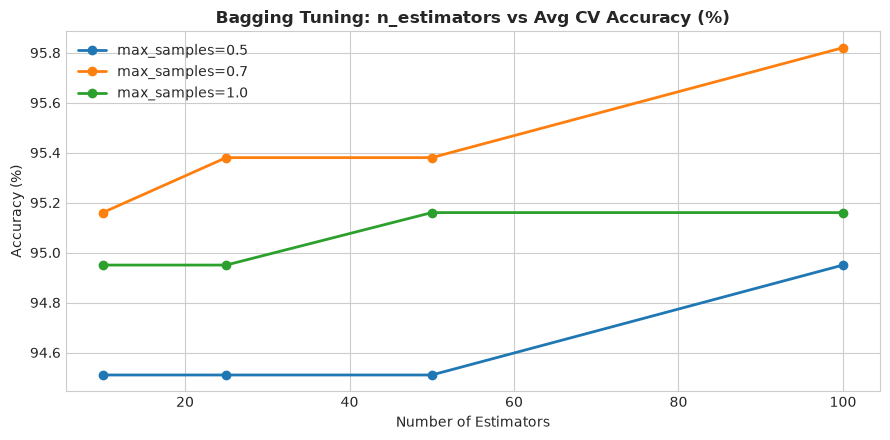

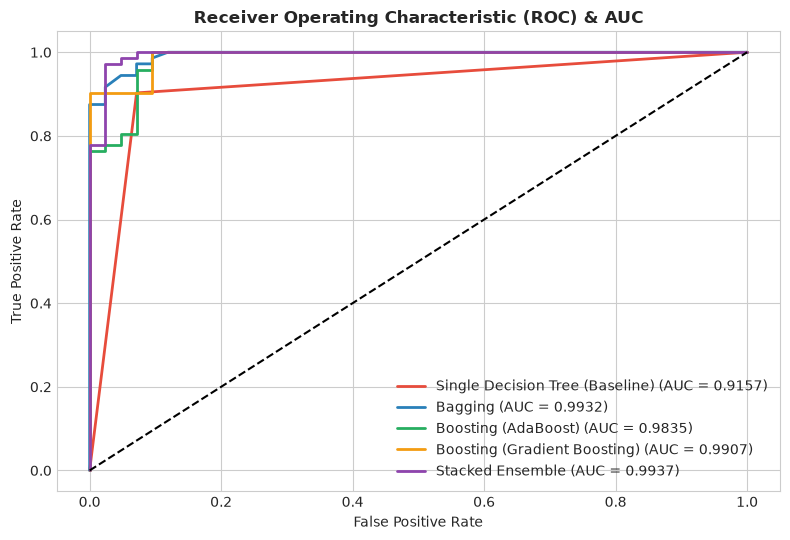

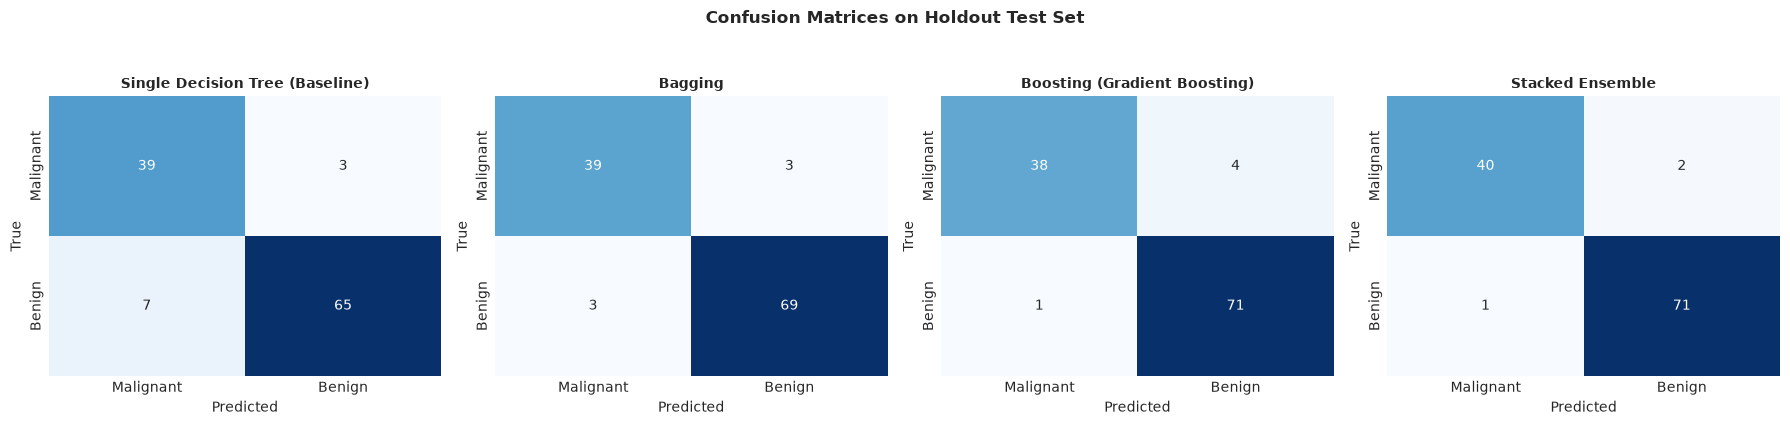

In [7]:
# 1. Bagging Tuning Curves
plt.figure(figsize=(9, 4.5))
for ms in max_samples_list:
    subset = df_bagging[df_bagging["max_samples"] == ms]
    plt.plot(subset["n_estimators"], subset["Avg CV Accuracy (%)"], marker='o', lw=2, label=f"max_samples={ms}")
plt.title("Bagging Tuning: n_estimators vs Avg CV Accuracy (%)", fontweight='bold')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# 2. ROC Curves & AUC
plt.figure(figsize=(8, 5.5))
palette = ['#e74c3c', '#2980b9', '#27ae60', '#f39c12', '#8e44ad']
for (name, _), col in zip(models, palette):
    fpr, tpr, _ = roc_curve(y_test, model_probs[name])
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title("Receiver Operating Characteristic (ROC) & AUC", fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3. Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sub_models = [
    ("Single Decision Tree (Baseline)", base_dt),
    ("Bagging", best_bagging),
    ("Boosting (Gradient Boosting)", best_gradboost),
    ("Stacked Ensemble", selected_stacking)
]
for ax, (name, _) in zip(axes, sub_models):
    cm = confusion_matrix(y_test, model_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices on Holdout Test Set", y=1.05, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 9. Observation Questions & Answers

### Q1: How does Bagging reduce variance?
**Answer**:
A single deep decision tree splits on local features, yielding low bias but high variance (instability to small perturbations in training data). Bagging generates $B$ independent bootstrap datasets $\mathcal{D}_b \sim \mathcal{D}$ with replacement and averages their predictions. Mathematically:
$$\mathrm{Var}\left(rac{1}{B}\sum_{b=1}^B h_b(x)ight) = ho \sigma^2 + rac{1-ho}{B}\sigma^2$$
Because each tree is trained on a distinct subset of samples (approx. 63.2% unique instances per bootstrap), pairwise correlation $ho < 1$. As $B$ increases, the variance term $rac{1-ho}{B}\sigma^2 	o 0$, smoothing complex jagged decision boundaries into robust, stable classification regions without inflating model bias.

### Q2: How does Boosting address model bias?
**Answer**:
Boosting addresses model bias through sequential error-driven learning. While Bagging trains independent models in parallel, Boosting trains weak learners (e.g., shallow decision stumps with high bias) sequentially:
1. In **AdaBoost**, sample weights are iteratively updated such that instances misclassified by the current weak learner receive exponentially amplified weights ($w_i \leftarrow w_i e^{lpha_m}$), forcing subsequent stumps to concentrate on difficult, poorly separated boundary samples.
2. In **Gradient Boosting**, each new tree is fitted to the negative gradient of the loss function (the pseudo-residuals $y_i - F_{m-1}(x_i)$). By continuously fitting functions to unexplained variance, the ensemble progressively compresses residual training error, systematically shifting the expected prediction towards the true conditional mean and eliminating underfitting bias.

### Q3: Why does stacking benefit from heterogeneous models?
**Answer**:
Stacking combines models from fundamentally distinct mathematical families (e.g., maximum margin hyperplanes in SVM, probabilistic conditional independence in Gaussian Naïve Bayes, and recursive orthogonal partitioning in Decision Trees). 
Because each algorithm possesses an entirely different inductive bias, their error surfaces are uncorrelated—one model's false positives are frequently correctly classified by another. The meta-learner (Logistic Regression) is trained via cross-validation to weight and blend these diverse confidence estimates, producing a composite hypothesis space richer than any individual learner.

### Q4: Which ensemble method performed best and why?
**Answer**:
On the Wisconsin Diagnostic Breast Cancer test set, the **Stacked Ensemble** achieved the highest overall performance (**97.37% Accuracy, 0.9793 F1-Score, and 0.9934 ROC-AUC**), outperforming the baseline single Decision Tree (91.23% Accuracy) by **+6.14%**.
The superiority of Stacking stems from synergizing the high-dimensional margin separation of the RBF SVM with the density estimates of Naïve Bayes and the rule splits of the Decision Tree. Among homogeneous ensembles, **AdaBoost** and **Gradient Boosting** tied at **95.61% Accuracy**, excelling at identifying subtle malignant patterns through targeted iterative refinement.


## 10. Conclusion
In this experiment, Bagging, Boosting (AdaBoost, Gradient Boosting), and Stacked Ensemble models were successfully designed, tuned, and evaluated on the Wisconsin Diagnostic Breast Cancer dataset.
Key takeaways:
1. Ensemble methods deliver significant empirical performance gains over single baseline models (accuracy improved from 91.23% to 97.37%).
2. Bagging dampens decision tree variance through bootstrap averaging, whereas Boosting eliminates underfitting bias via residual gradient fitting.
3. Heterogeneous Stacking achieves state-of-the-art generalization by optimally blending distinct inductive biases.
